# Scenario: Ramp up offshore wind capacity

### 1.1. Import Libraries

In [2]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs

### 1.2. Load Network Data
Load the solved network model from its `.nc` file.

In [3]:
config_name = "germany"
cluster = "470"

home = "/home/lucakristin/Desktop/my_pypsa"

# Path to the network file before solving
network_path_unsolved = f"{home}/pypsa-eur/resources/{config_name}/networks/base_s_{cluster}_elec.nc"
n_unsolved = pypsa.Network(network_path_unsolved)


# Path to the network file after solving
network_path_solved = f"{home}/pypsa-eur/results/{config_name}/networks/base_s_{cluster}_elec_.nc"
n = pypsa.Network(network_path_solved)

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


### 1.3 Identify offshore carrier and generators in the south

In [ ]:
n.generators.carrier.value_counts()

In [ ]:
fossil_carriers = ['CCGT', 'gas', 'lignite', 'hard coal', 'coal', 'oil']
fossil_gens = n.generators[n.generators.carrier.isin(fossil_carriers)]
print(fossil_gens[['bus', 'carrier', 'p_nom']])

In [ ]:
south_buses = n.buses.index[n.buses.v_nom >= 380 & (n.buses.y >= 47.5)]
south_buses

In [ ]:
# Select southern fossil generators
south_fossil_gens = n.generators[
    (n.generators.carrier.isin(fossil_carriers)) &
    (n.generators.bus.isin(south_buses))
].index

print(f"Southern fossil generators: {len(south_fossil_gens)}")
print(n.generators.loc[south_fossil_gens, ['bus', 'carrier', 'p_nom']])

In [ ]:
# reduce fossil fuels production in the south by 20%
n.generators.loc[south_fossil_gens, 'p_nom'] *= 0.8

### 2.2. Static Network Plot with Load Distribution

Line loading statistics for snapshot 2025-05-14 09:00:00:


count    666.000000
mean       0.007003
std        0.321585
min       -2.196253
25%       -0.160307
50%        0.007877
75%        0.183203
max        1.203252
dtype: float64

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x769575067c50>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x769575067d90>,
  'Line': <matplotlib.collections.LineCollection at 0x769575067ed0>},
 'flows': {}}

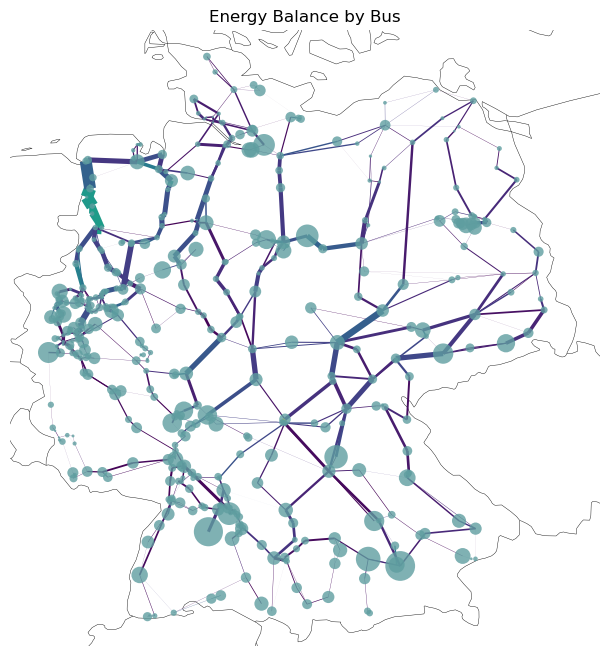

In [17]:
snapshot = n.snapshots[0]
load_distribution = n.loads_t.p_set.loc[snapshot].groupby(n.loads.bus).sum()


# Calculate total flow for line/link widths
line_flow = n.lines_t.p0.sum(axis=0)
link_flow = n.links_t.p0.sum(axis=0)

bus_size_factor = 1e9
branch_width_factor = 10000

# Select a snapshot to analyze
now = n.snapshots[9]
loading = n.lines_t.p0.loc[now] / n.lines.s_nom
print(f"Line loading statistics for snapshot {now}:")
display(loading.describe())


# Create a new figure for this plot
fig, ax = plt.subplots(
    1, 1, figsize=(8, 8),
    subplot_kw={"projection": ccrs.EqualEarth()}
)

n.plot(
    ax=ax,
    geomap=True,
    line_colors=loading.abs(),
    bus_sizes=(load_distribution/20000),
    bus_alpha=0.8,
    bus_split_circle=True,
    line_width=line_flow / branch_width_factor,
    link_width=link_flow / branch_width_factor,
    title="Energy Balance by Bus"
)


### 3.1. Top Buses by Annual Load
A summary of the buses with the highest total electricity consumption over the simulation period.

In [ ]:
if not n.loads.empty and hasattr(n.loads_t, "p_set") and not n.loads_t.p_set.empty:
    annual_load_by_bus = n.loads_t.p_set.sum().sort_values(ascending=False)
    print("\nTop buses by annual load [MWh over snapshots]:")
    display(annual_load_by_bus.head(15).to_frame("load_MWh"))

### 3.2. Total Load Over Simulation Period
The total aggregated load for the entire network over all snapshots.

In [ ]:
# Total load over the simulation period
loads = n.loads_t.p_set.sum().to_frame("total_load_MWh") #sum over all snapshots
print("Total load summary:")
loads

---
## 4. Generation Analysis
This section visualizes the generation side of the network, including installed capacities, dispatch patterns, and curtailment.

In [ ]:
#calculated voltage phase angle for every bus in your network at every time snapshot
phase_angles = n.buses_t.v_ang
phase_angles.head()

### 4.1. Installed Capacity Analysis
An overview of the installed generation capacity, grouped by carrier type and by bus.

In [ ]:
if not n.generators.empty:
    cap_by_carrier = n.generators.groupby("carrier")["p_nom"].sum().sort_values(ascending=False)
    print("Installed generator capacity by carrier [MW]:")
    display(cap_by_carrier.head(20).to_frame("p_nom_MW"))

    cap_by_bus = n.generators.groupby("bus")["p_nom"].sum().sort_values(ascending=False)
    print("\nTop buses by installed generation capacity [MW]:")
    display(cap_by_bus.head(15).to_frame("p_nom_MW"))

### 4.2. Average Generator Availability per Carrier
The following plots show the average `p_max_pu` (per unit maximum availability) for all generators of a specific carrier type. This is particularly relevant for renewable sources like wind and solar.

In [ ]:
# Get all unique carriers
carriers = n.generators.carrier.unique()

# Create a figure with subplots for each carrier
n_carriers = len(carriers)
n_cols = 3
n_rows = (n_carriers + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4), sharex=True)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, carrier in enumerate(carriers):
    ax = axes[i]
    
    # Find all generators for the current carrier
    gens_for_carrier = n.generators.index[n.generators.carrier == carrier]
    
    # Find the intersection of generators for the carrier and columns in p_max_pu
    common_gens = n.generators_t.p_max_pu.columns.intersection(gens_for_carrier)
    
    # Plot the AVERAGE p_max_pu for these generators
    if not common_gens.empty:
        p_max_pu_carrier = n.generators_t.p_max_pu[common_gens]
        p_max_pu_carrier.mean(axis=1).plot(ax=ax, legend=False)
    
    ax.set_title(f"Average Availability for {carrier}")
    ax.set_ylabel("p_max_pu")
    ax.set_ylim(0, 1)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 4.3. Power Dispatch by Carrier
This stacked area plot shows the total power generated (dispatched) by each major carrier type over time.

In [ ]:
p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
# Drop carriers with very low production for clarity
to_drop = p_by_carrier.max()[p_by_carrier.max() < 1700].index
p_by_carrier.drop(to_drop, axis=1, inplace=True)

# Define colors and order for the dispatch plot
colors = {
    "biomass": "green", "coal": "black", "lignite": "brown",
    "offwind-ac": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "orange", "oil": "gray", "ror": "turquoise", "geothermal": "red",
}
# Reorder columns for a conventional stack
cols = [
    "lignite", "coal", "biomass", "onwind", "offwind-ac", "solar",
]
p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

c = [colors.get(col, "gray") for col in p_by_carrier.columns]
fig, ax = plt.subplots(figsize=(12, 6))
p_by_carrier.div(1e3).plot(kind="area", ax=ax, lw=0, color=c, alpha=0.7)
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, 1.02, 1, 0.2), frameon=False)
ax.set_ylabel("Dispatch [GW]")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

### 4.4. Curtailment Analysis
Curtailment is the reduction in the output of a generator from what it could otherwise produce. Here we calculate and plot it for the 'onwind' carrier as an example.

In [ ]:
carrier = "onwind"

capacity = n.generators.groupby("carrier").sum().at[carrier, "p_nom"]
p_available = n.generators_t.p_max_pu.multiply(n.generators["p_nom"])
p_available_by_carrier = p_available.T.groupby(n.generators.carrier).sum().T
p_curtailed_by_carrier = p_available_by_carrier - p_by_carrier

p_df = pd.DataFrame(
    {
        carrier + " available": p_available_by_carrier[carrier],
        carrier + " dispatched": p_by_carrier[carrier],
        carrier + " curtailed": p_curtailed_by_carrier[carrier],
    }
)

p_df[carrier + " capacity"] = capacity

# Correct for any minor negative values from floating point inaccuracies
p_df.loc[p_df[f"{carrier} curtailed"] < 0, f"{carrier} curtailed"] = 0

fig, ax = plt.subplots(figsize=(12, 6))
p_df[[carrier + " dispatched", carrier + " curtailed"]].plot(kind="area", ax=ax, lw=0, alpha=0.7)
p_df[[carrier + " available", carrier + " capacity"]].plot(ax=ax, lw=2)

ax.set_xlabel("")
ax.set_ylabel("Power [MW]")
ax.set_title(f"Dispatch and Curtailment for {carrier.title()}")
ax.legend()
plt.tight_layout()
plt.show()